# <b><u> Project Objective <b><u>

The objective of this project is to analyze ride booking patterns for Ola Cabs to identify factors contributing to ride cancellations, incomplete rides, booking values, and customer behavior. The analysis combines exploratory data analysis and statistical testing to uncover actionable insights that can help improve operational efficiency, reduce revenue leakage, and enhance customer experience.

# Importing Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

# Loading Dataset 

In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Projects/Ola Cabs/Dataset.csv')

In [3]:
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Unnamed: 20
0,2024-07-26,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,#NAME?,NaN
1,2024-07-25,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,NaN,No,NaN,158,Cash,13,4.1,4.0,#NAME?,NaN
2,2024-07-30,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,NaN,No,NaN,386,UPI,40,4.2,4.8,#NAME?,NaN
3,2024-07-22,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,NaN,NaN,NaN,384,NaN,0,NaN,NaN,#NAME?,NaN
4,2024-07-02,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,NaN,No,NaN,822,Credit Card,45,4.0,3.0,#NAME?,NaN


# About Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Date                        103024 non-null  object 
 1   Time                        103024 non-null  object 
 2   Booking_ID                  103024 non-null  object 
 3   Booking_Status              103024 non-null  object 
 4   Customer_ID                 103024 non-null  object 
 5   Vehicle_Type                103024 non-null  object 
 6   Pickup_Location             103024 non-null  object 
 7   Drop_Location               103024 non-null  object 
 8   V_TAT                       63967 non-null   float64
 9   C_TAT                       63967 non-null   float64
 10  Canceled_Rides_by_Customer  10499 non-null   object 
 11  Canceled_Rides_by_Driver    18434 non-null   object 
 12  Incomplete_Rides            63967 non-null   object 
 13  Incomplete_Rid

In [5]:
df.describe()

,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating,Unnamed: 20
count,63967.000000,63967.000000,103024.000000,103024.000000,63967.000000,63967.000000,0.0
mean,170.876952,84.873372,548.751883,14.189927,3.997457,3.998313,NaN
std,80.803640,36.005100,536.541221,15.776270,0.576834,0.578957,NaN
min,35.000000,25.000000,100.000000,0.000000,3.000000,3.000000,NaN
25%,98.000000,55.000000,242.000000,0.000000,3.500000,3.500000,NaN
50%,168.000000,85.000000,386.000000,8.000000,4.000000,4.000000,NaN
75%,238.000000,115.000000,621.000000,26.000000,4.500000,4.500000,NaN
max,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000,NaN


## <u><b>Validated Numerical Columns <b><u>

**Reason:**
Before performing exploratory data analysis and statistical testing, the numerical variables were reviewed to verify their data quality. This validation ensured that the columns had appropriate data types, contained values within expected business ranges, and did not exhibit obvious abnormalities or inconsistencies that could affect the accuracy of the analysis.

**Action Taken:**
Generated descriptive statistics for all numerical variables using the describe() function.
Reviewed key statistical measures, including:  
Count  
Mean  
Standard Deviation  
Minimum and Maximum values  
Quartiles (25%, 50%, and 75%)  
Compared the observed ranges against expected business values to identify potential anomalies, invalid entries, or unrealistic observations.
Verified whether any numerical columns required further data type conversion or additional cleaning before analysis.  

**Observations:**
Numerical columns were found to have appropriate value ranges based on the business context.
Customer and driver ratings were constrained between 3.0 and 5.0, indicating no invalid rating values.
Booking values ranged from ₹100 to ₹2,999, which appeared reasonable for the available ride types.
Ride distances ranged from 0 km to 49 km. Records with a distance of 0 km were retained, as they may represent cancelled or incomplete rides rather than data entry errors.
Vehicle turnaround time (V_TAT) and customer turnaround time (C_TAT) fell within expected operational limits.
No additional data type conversions or corrections were required for the numerical variables.

**Impact:**
This validation confirmed that the numerical features were suitable for analysis without requiring further preprocessing. Verifying value ranges and summary statistics helped ensure the reliability of subsequent visualizations, business insights, and statistical tests.

# Data Cleaning and Preparation

In [6]:
import data_profiling
from data_profiling import ProfileReport

profile = ProfileReport(df, title = 'Profile Report')

In [7]:
df.drop(columns = ['Vehicle Images', 'Unnamed: 20'], inplace = True)

The columns **Vehicle Images** and **Unnamed: 20** were removed from the dataset as they did not provide any analytical value for this project. 

The Vehicle Images column contained image references that were not relevant to the analysis, while Unnamed: 20 was an empty/unintended column generated during data export. Removing these columns reduced unnecessary data and improved the overall quality and readability of the dataset.

In [8]:
df['Ride_Status'] = np.select(
    [
        df['Canceled_Rides_by_Customer'].notna() |
        df['Canceled_Rides_by_Driver'].notna(),

        df['Incomplete_Rides_Reason'].notna()
    ],
    [
        'Cancelled',
        'Incomplete'
    ],
    default='Completed'
)

# Resoning Column
df['Outcome_Reason'] = (
    df['Canceled_Rides_by_Customer']
      .fillna(df['Canceled_Rides_by_Driver'])
      .fillna(df['Incomplete_Rides_Reason'])
)

# Drop the original columns
df.drop(
    columns=[
        'Canceled_Rides_by_Customer',
        'Canceled_Rides_by_Driver',
        'Incomplete_Rides',
        'Incomplete_Rides_Reason'
    ],
    inplace=True
)

## 1. Step: Consolidated Ride Outcome Information

**Reason:**
The dataset contained multiple columns representing different ride outcomes, including customer cancellations, driver cancellations, incomplete rides, and their corresponding reasons. Storing this information across several columns introduced redundancy and made subsequent analysis more complex. To simplify the dataset and create a unified representation of ride outcomes, these columns were consolidated into two new variables.

**Action Taken:**
Created a new column, Ride_Status, to classify every booking into one of three categories:
Completed – Ride completed successfully.
Cancelled – Ride cancelled by either the customer or the driver.
Incomplete – Ride was not completed due to operational issues.
Created a new column, Outcome_Reason, by combining the cancellation and incomplete ride reason columns into a single field. This ensured that each non-completed ride retained its associated reason while eliminating duplicate information.  

Dropped the original columns:  
Canceled_Rides_by_Customer, Canceled_Rides_by_Driver, Incomplete_Rides, Incomplete_Rides_Reason as their information had been successfully consolidated into the newly created variables.

**Impact:**
This transformation reduced data redundancy, improved the readability of the dataset, and created two standardized variables that simplify downstream analysis. The consolidated Ride_Status enables straightforward performance analysis of completed, cancelled, and incomplete rides, while Outcome_Reason provides a single source for investigating the causes of unsuccessful rides.

In [9]:
df['DateTime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str)
)

df.drop(columns = ['Date', 'Time'], inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Booking_ID       103024 non-null  object        
 1   Booking_Status   103024 non-null  object        
 2   Customer_ID      103024 non-null  object        
 3   Vehicle_Type     103024 non-null  object        
 4   Pickup_Location  103024 non-null  object        
 5   Drop_Location    103024 non-null  object        
 6   V_TAT            63967 non-null   float64       
 7   C_TAT            63967 non-null   float64       
 8   Booking_Value    103024 non-null  int64         
 9   Payment_Method   63967 non-null   object        
 10  Ride_Distance    103024 non-null  int64         
 11  Driver_Ratings   63967 non-null   float64       
 12  Customer_Rating  63967 non-null   float64       
 13  Ride_Status      103024 non-null  object        
 14  Outcome_Reason   328

## 2. Step: Combined Date and Time into a Unified DateTime Column

**Reason:**
The dataset stored the date and time of each booking in two separate columns. While this format is suitable for data entry, it is not ideal for analytical tasks such as time-series analysis, extracting temporal features, or identifying booking trends. Combining these columns into a single DateTime variable provides a standardized timestamp for each booking and improves the efficiency of subsequent analysis.

**Action Taken:**
Combined the Date and Time columns into a single DateTime column using the pd.to_datetime() function.
Converted the resulting values to the datetime64[ns] data type to enable datetime operations.
Removed the original Date and Time columns, as their information was fully preserved within the newly created DateTime column.

In [10]:
df['DOW'] = df['DateTime'].dt.dayofweek
df.head()

,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Ride_Status,Outcome_Reason,DateTime,DOW
0,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,444,NaN,0,NaN,NaN,Cancelled,Personal & Car related issue,2024-07-26 14:00:00,4
1,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,158,Cash,13,4.1,4.0,Completed,NaN,2024-07-25 22:20:00,3
2,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,386,UPI,40,4.2,4.8,Completed,NaN,2024-07-30 19:59:00,1
3,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,384,NaN,0,NaN,NaN,Cancelled,Driver is not moving towards pickup location,2024-07-22 03:15:00,0
4,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,822,Credit Card,45,4.0,3.0,Completed,NaN,2024-07-02 09:02:00,1


## 3. Step: Extracted Day of Week (DOW)

**Reason:**
To support temporal analysis, the Day of Week (DOW) was extracted from the DateTime column. This feature enables the analysis of booking patterns across different days of the week, helping identify variations in customer demand and operational performance between weekdays and weekends.

**Action Taken:**
Derived a new column, DOW, from the DateTime column using the dayofweek attribute.
The extracted values range from 0 to 6, where:  
0 = Monday  
1 = Tuesday  
2 = Wednesday  
3 = Thursday  
4 = Friday  
5 = Saturday  
6 = Sunday  

# <u><b> EDA <b><u>

# 1. Evaluating the Relationship Between Categorical Variables and Booking Value.


**Objective**
The objective of this analysis was to determine whether the Booking Value differed significantly across various categorical variables. Since Booking Value is a continuous variable and preliminary analysis indicated that the assumptions required for parametric tests were not satisfied, the Kruskal–Wallis H Test was selected as a non-parametric alternative to one-way ANOVA.

**Null Hypothesis (H₀):**
There is no statistically significant difference in the distribution of Booking Value across the categories of the selected categorical variable.

**Alternative Hypothesis (H₁):** 
There is a statistically significant difference in the distribution of Booking Value across the categories of the selected categorical variable.

In [11]:
columns = ['Booking_Status', 'Vehicle_Type','Pickup_Location', 'Drop_Location', 'Payment_Method', 'Ride_Status', 'Outcome_Reason']

def multiple_kruskal(data, dv, columns):
    result = []
    for cols in columns:
        output = pg.kruskal(data = data, dv = dv, between = cols)
        result.append(output)
        output['Status'] = np.where(output['p_unc'] <= 0.05, 'Rejected', 'Fail to Reject')

    result = pd.concat(result, ignore_index = True)   
    return result

multiple_kruskal(df, 'Booking_Value', columns)

,Source,ddof1,H,p_unc,Status
0,Booking_Status,3,0.895819,0.826437,Fail to Reject
1,Vehicle_Type,6,6.791528,0.340558,Fail to Reject
2,Pickup_Location,49,49.180497,0.465893,Fail to Reject
3,Drop_Location,49,55.866889,0.232594,Fail to Reject
4,Payment_Method,3,4.921258,0.177655,Fail to Reject
5,Ride_Status,2,8.443585,0.014672,Rejected
6,Outcome_Reason,11,18.841855,0.063992,Fail to Reject


**Results and Interpretation**

The Kruskal–Wallis H Test was performed to determine whether Booking Value differed significantly across various categorical variables at a 5% significance level (α = 0.05).

The results indicate that Ride Status was the only categorical variable found to have a statistically significant association with Booking Value (H = 8.44, p = 0.0147). Since the p-value is less than 0.05, the null hypothesis was rejected, suggesting that the distribution of Booking Value differs across the ride status categories (Completed, Cancelled, and Incomplete).

For all other categorical variables—including Booking Status, Vehicle Type, Pickup Location, Drop Location, Payment Method, and Outcome Reason—the p-values exceeded the significance threshold of 0.05. Therefore, the null hypothesis failed to be rejected for these variables, indicating insufficient statistical evidence to conclude that Booking Value differs significantly across their respective categories.

**Business Insight**

Among all the categorical variables examined, Ride Status emerged as the only factor significantly associated with Booking Value. This suggests that completed, cancelled, and incomplete rides exhibit different booking value distributions, making Ride Status an important variable for further investigation. A post-hoc pairwise comparison can be performed to identify which specific ride status categories differ significantly from one another. The remaining categorical variables did not demonstrate statistically significant differences in Booking Value within this dataset.

In [12]:
pg.pairwise_tests(data = df, dv = 'Booking_Value', between = 'Ride_Status', padjust = 'bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Ride_Status,Cancelled,Completed,False,True,1.367902,53356.130483,two-sided,0.171349,0.514046,bonf,0.02,0.009604
1,Ride_Status,Cancelled,Incomplete,False,True,-2.283866,4951.026252,two-sided,0.022422,0.067265,bonf,0.26,-0.040161
2,Ride_Status,Completed,Incomplete,False,True,-2.920628,4327.140247,two-sided,0.003511,0.010534,bonf,1.31,-0.050344


**Interpretation**

The post-hoc analysis revealed that, after applying the Bonferroni correction to control for multiple comparisons, only the comparison between Completed and Incomplete rides remained statistically significant (adjusted p = 0.011).
  
No statistically significant differences were observed between:

Cancelled and Completed rides (adjusted p = 0.514)  
Cancelled and Incomplete rides (adjusted p = 0.067)  

Although the Cancelled vs Incomplete comparison was significant before adjustment, it did not remain significant after applying the Bonferroni correction, indicating that the observed difference may have been due to multiple testing.

**Business Insight**

The significant Kruskal–Wallis result is primarily driven by the difference in Booking Value between Completed and Incomplete rides. This suggests that incomplete rides tend to occur within a different booking value distribution compared to successfully completed rides. Understanding why higher or lower value bookings are more likely to become incomplete could help the business identify operational inefficiencies, reduce ride failures, and improve revenue realization.

## 1.1. Analysis of Booking Value Across Ride Status Categories

In [13]:
rs = df.groupby('Ride_Status', dropna = False)['Booking_Value'].sum().reset_index(name = 'Total_Booking_Value')
rs['Percentage'] = (rs['Total_Booking_Value'] / rs['Total_Booking_Value'].sum()
    * 100
).round(2)
rs

,Ride_Status,Total_Booking_Value,Percentage
0,Cancelled,15954328,28.22
1,Completed,38329804,67.80
2,Incomplete,2250482,3.98


In [14]:
from scipy.stats import chisquare

counts = df['Ride_Status'].value_counts()

observed = [
    counts['Cancelled'],
    counts['Completed'],
    counts['Incomplete']
]

expected = [
    sum(observed) * 0.20,
    sum(observed) * 0.78,
    sum(observed) * 0.02
]

chi2, p = chisquare(f_obs=observed, f_exp=expected)
print(chi2)
print(p)

6348.260983002216
0.0


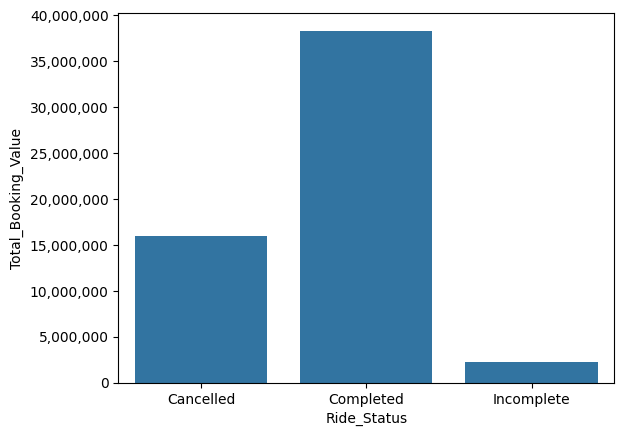

In [15]:
from matplotlib.ticker import StrMethodFormatter

ax = sns.barplot(data = rs, x = 'Ride_Status', y = 'Total_Booking_Value')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.show()

**Findings**  
Completed rides contributed the highest share of the total booking value, accounting for ₹38.33 million (67.80%), indicating that the majority of revenue is generated from successfully completed trips.
Cancelled rides represented ₹15.95 million (28.22%) of the total booking value, highlighting a substantial volume of bookings that failed to convert into completed rides. This suggests a significant opportunity to improve operational efficiency and revenue realization by reducing cancellations.
Incomplete rides contributed the smallest share at ₹2.25 million (3.98%), indicating that although relatively infrequent, these rides still represent unrealized booking value that could potentially be recovered through process improvements.

**Business Insight**  
Nearly one-third (32.20%) of the total booking value is associated with cancelled or incomplete rides. Reducing ride cancellations and operational failures could increase the proportion of booking value that is successfully converted into completed rides, thereby improving revenue realization without necessarily increasing booking demand.

This is a strong business insight because it connects the ride lifecycle directly to revenue performance and identifies cancellations as a potential area for operational improvement.

# 2. Relationship Between DOW and Booking Value.¶

**Null Hypothesis (H₀)**  
There is no statistically significant difference in the distribution of Booking Value across the days of the week.

**Alternative Hypothesis (H₁)**  
There is a statistically significant difference in the distribution of Booking Value across the days of the week.

In [16]:
pg.kruskal(data = df, dv = 'Booking_Value', between = 'DOW')

,Source,ddof1,H,p_unc
Kruskal,DOW,6,6.760969,0.343519


**Interpretation**

The Kruskal–Wallis H Test was conducted to determine whether Booking Value differed significantly across the days of the week.

The results showed no statistically significant difference in the distribution of Booking Value across the seven days of the week (H(6) = 6.761, p = 0.344). Therefore, the null hypothesis failed to be rejected.

**Business Insight**

The analysis suggests that the day of the week does not have a significant influence on Booking Value within this dataset. In other words, customers appear to spend similar amounts on bookings regardless of whether the ride is booked on a weekday or weekend. This indicates that pricing or fare values remain relatively consistent throughout the week, and other factors—such as ride distance, vehicle type, demand, or time of day—are likely to have a greater impact on Booking Value than the day on which the booking was made.

In [17]:
df['Is_Weekend'] = np.where(df['DOW'].isin([5, 6]), 'Yes', 'No')

# 3. Correlation Analysis of Driver and Customer Ratings

**Objective:** Determine whether higher-rated drivers also receive higher customer ratings, indicating alignment between driver performance and customer satisfaction.

In [18]:
new_df = df.copy()
new_df['Driver_Ratings'] = new_df['Driver_Ratings'].fillna(new_df['Driver_Ratings'].mean()).round(1)
new_df['Customer_Rating'] = new_df['Customer_Rating'].fillna(new_df['Customer_Rating'].mean()).round(1)

# np.corrcoef(new_df['Booking_Value'], new_df['Ride_Distance'], new_df['Driver_Ratings'], new_df['Customer_Rating'])
result1 = np.corrcoef(new_df['Driver_Ratings'], new_df['Customer_Rating'])
temp = df[['Driver_Ratings', 'Customer_Rating']].dropna()

result2 = np.corrcoef(temp['Driver_Ratings'],temp['Customer_Rating'])
print(result2)
print(result1)

[[ 1.         -0.00280656]
 [-0.00280656  1.        ]]
[[ 1.         -0.00280168]
 [-0.00280168  1.        ]]


**Business Interpretation**

Spearman's correlation analysis indicated no meaningful association between Driver Ratings and Customer Ratings. The correlation coefficient was close to zero, suggesting that higher driver ratings do not necessarily correspond to higher customer ratings within the dataset. This implies that the two rating systems appear to evaluate different aspects of the ride experience and should be analyzed independently rather than being treated as interchangeable measures of service quality.

# 4. Analysis of Booking Value by Ride Status and Payment Method

**Objective**

To analyze how booking value varies across ride statuses, payment methods, and vehicle types, with a primary focus on identifying patterns in cancelled and incomplete rides that can help reduce revenue leakage and improve ride completion rates.

In [19]:
payment_summary = (
    df.groupby(['Ride_Status', 'Payment_Method'], dropna=False)['Booking_Value']
        .sum()
        .reset_index(name='Total_Booking_Value')
)
payment_summary['Payment_Method'] = payment_summary['Payment_Method'].fillna('Unknown')

payment_summary['Percentage'] = (
    payment_summary['Total_Booking_Value']
    / payment_summary.groupby('Ride_Status')['Total_Booking_Value'].transform('sum')
    * 100
).round(2)

payment_summary

,Ride_Status,Payment_Method,Total_Booking_Value,Percentage
0,Cancelled,Unknown,15954328,100.00
1,Completed,Cash,18030231,47.04
2,Completed,Credit Card,1230365,3.21
3,Completed,Debit Card,316057,0.82
4,Completed,UPI,13253332,34.58
5,Completed,Unknown,5499819,14.35
6,Incomplete,Cash,1230085,54.66
7,Incomplete,Credit Card,82428,3.66
8,Incomplete,Debit Card,22865,1.02
9,Incomplete,UPI,915104,40.66


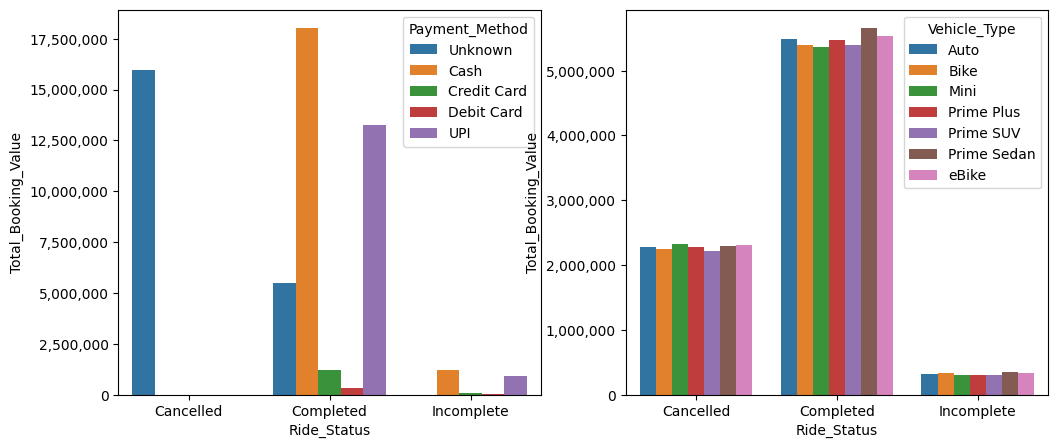

In [20]:
from matplotlib.ticker import StrMethodFormatter

fig, ax = plt.subplots(1, 2, figsize = (12, 5))

payment_vis = sns.barplot(data = payment_summary, x = 'Ride_Status', y = 'Total_Booking_Value', hue = 'Payment_Method', ax = ax[0])
payment_vis.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Creating a Second plot For Analysing the Vehicle Type and Ride Status
vehicle_summary = df.groupby(['Ride_Status', 'Vehicle_Type'])['Booking_Value'].sum().reset_index(name = 'Total_Booking_Value')
vehicle_vis = sns.barplot(data = vehicle_summary, x = 'Ride_Status', y = 'Total_Booking_Value', hue = 'Vehicle_Type', ax = ax[1])
vehicle_vis.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.show()

**Key Findings**  
- Cancelled rides were predominantly associated with the Unknown payment method, accounting for approximately 16 million in booking value. In contrast, cancelled bookings across all other payment methods were negligible.
- Incomplete rides generated relatively low booking values, with Cash (1.2 million) and UPI (0.9 million) contributing the largest share, while Credit Card and Debit Card transactions remained minimal.
- Among completed rides, Cash generated the highest booking value (approximately 18.1 million), followed by UPI (13.2 million), demonstrating that these are the platform's primary revenue-generating payment methods.
- Across all vehicle categories, cancelled ride booking values remained relatively consistent at approximately 2.2–2.3 million, indicating that cancellations are not concentrated within any specific vehicle type.
- Similarly, incomplete rides contributed approximately 0.3 million in booking value across each vehicle category, showing minimal variation between vehicle types.
- The difference in completed booking value across vehicle categories was only around 5%, suggesting that vehicle type has little influence on booking revenue or cancellation patterns.

**Business Recommendation**  
- Prioritize reducing cancellations associated with the Unknown payment method by encouraging customers to select or verify a payment method earlier in the booking process.
- Investigate the causes of incomplete rides for Cash and UPI transactions, as these payment methods account for the majority of incomplete booking value.
- Implement proactive interventions such as booking confirmations, payment validation, driver assignment optimization, or customer notifications before ride cancellation occurs.
- Since cancellations are evenly distributed across vehicle types, focus operational improvements on the overall booking and payment workflow rather than targeting a specific vehicle category.
- Track Cancelled Booking Value and Incomplete Booking Value as key operational KPIs to measure the effectiveness of initiatives aimed at improving ride completion and minimizing revenue leakage.

# 5. Ride Distance Analysis 

<Axes: >

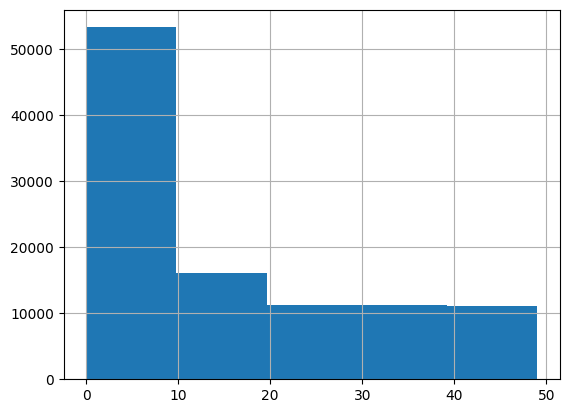

In [21]:
df['Ride_Distance'].hist(bins = 5)

## Distribution of Ride Distance

A histogram was plotted to examine the distribution of the Ride Distance variable before conducting further analysis.

**Findings**  
The histogram shows that the majority of rides are concentrated within short travel distances, particularly below 10 km.
As ride distance increases, the frequency of rides gradually decreases, indicating a right-skewed distribution.
Comparatively fewer rides fall into the higher distance ranges (20–50 km), suggesting that long-distance trips occur less frequently than short-distance trips.
Since ride distance is a continuous variable with a wide range of values, directly comparing individual distances would provide limited business insight.

**Creating Distance Brackets for Better Analysis**  
To facilitate a more meaningful business analysis, the continuous Ride Distance variable was grouped into 10 km intervals using the following brackets:  
0–10 km  
10–20 km  
20–30 km  
30–40 km  
40–50 km  

This categorization simplifies the analysis by grouping rides into comparable distance ranges, making it easier to evaluate booking value, booking frequency, customer behavior, and other business metrics across different trip lengths.

In [22]:
# Creating Brackets for Better Analysis
bins = [0, 10, 20, 30, 40, 50]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50']

df['Distance_Bracket'] = pd.cut(
    df['Ride_Distance'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [23]:
grouping = df.groupby('Distance_Bracket')['Booking_Value'].sum().reset_index(name = 'Total_Booking_Value')
grouping

C:\Users\Adity\AppData\Local\Temp\ipykernel_11640\2613518445.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouping = df.groupby('Distance_Bracket')['Booking_Value'].sum().reset_index(name = 'Total_Booking_Value')


,Distance_Bracket,Total_Booking_Value
0,0-10,30280653
1,10-20,8450925
2,20-30,6037532
3,30-40,6188873
4,40-50,5576631


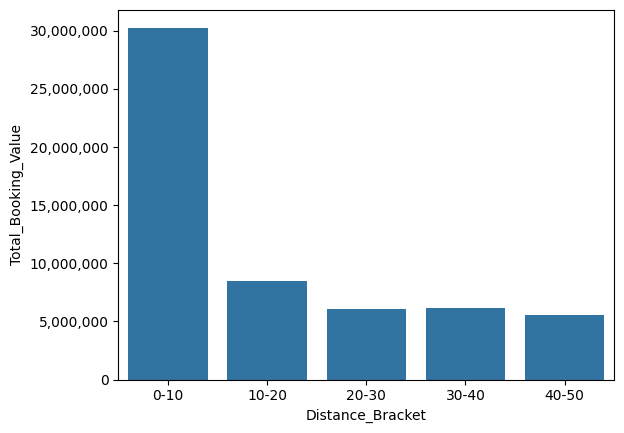

In [24]:
ax = sns.barplot(data = grouping, x = 'Distance_Bracket', y = 'Total_Booking_Value')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.show()

**Findings**  
Rides within the 0–10 km distance bracket generated the highest booking value, contributing approximately ₹30.28 million, significantly outperforming all other distance categories.
Booking value declined considerably beyond 10 km, with the 10–20 km bracket contributing ₹8.45 million.
The 20–30 km, 30–40 km, and 40–50 km distance brackets generated relatively similar booking values, ranging between ₹5.58 million and ₹6.19 million.
The dominance of the 0–10 km category is primarily driven by the substantially higher volume of short-distance rides, as observed in the ride distance distribution, rather than higher fares per trip.

**Business Insight**  
The analysis indicates that short-distance rides form the core source of booking revenue, with the majority of total booking value generated from trips under 10 km. This suggests that Ola's business relies heavily on high-frequency, short-distance travel.

Although longer-distance rides typically command higher fares on an individual basis, their lower booking frequency results in a comparatively smaller contribution to overall booking value. Therefore, strategies aimed at increasing demand and operational efficiency for short-distance rides are likely to have the greatest impact on total revenue, while promotional campaigns could be explored to encourage greater adoption of medium- and long-distance trips.

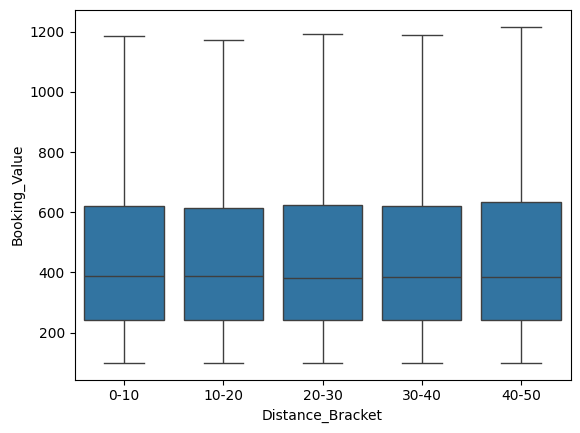

In [25]:
sns.boxplot(data = df, x = 'Distance_Bracket', y = 'Booking_Value', showfliers = False)
plt.show()

## Distribution of Booking Value Across Ride Distance Categories

A boxplot was created to compare the distribution of Booking Value across the different Ride Distance brackets while excluding outliers for improved visualization.

**Findings**  
- The median booking value remains relatively consistent across all ride distance brackets, indicating that the typical booking value does not vary substantially with ride distance.
- The interquartile ranges (IQRs) are also very similar across the five distance categories, suggesting that the variability in booking values is comparable regardless of ride distance.
- Each distance bracket exhibits a similar overall spread, with booking values extending across a broad range. This indicates that customers within each distance category make bookings with varying monetary values.
- The 40–50 km distance bracket shows a slightly higher upper whisker compared to the other categories, suggesting the presence of comparatively higher booking values for some long-distance rides, although the overall distribution remains similar.

**Business Insight**  
While shorter-distance rides generate the highest total booking value due to their significantly higher booking volume, the distribution of individual booking values is remarkably similar across all ride distance categories. This suggests that the higher revenue from short-distance rides is primarily driven by ride frequency rather than substantially higher booking values per ride.

The boxplot also indicates that ride distance alone does not appear to be a strong differentiator of booking value, implying that other factors—such as vehicle type, pricing policies, surge pricing, or ride duration—may have a greater influence on the amount customers spend per booking.


# Testing if Booking Values is Assocaited to Distance Brackets 

## Interpretation

**Null Hypothesis (H₀):** The distribution of booking values is the same across all distance brackets.  
**Alternative Hypothesis (H₁):** At least one distance bracket has a different distribution of booking values.

In [26]:
pg.kruskal(data = df, dv = 'Booking_Value', between = 'Distance_Bracket')

,Source,ddof1,H,p_unc
Kruskal,Distance_Bracket,4,0.899711,0.924602


## Business Interpretation

The analysis suggests that booking values do not differ significantly across different travel distance brackets. In other words, customers travelling short or long distances tend to spend similar amounts on bookings.

# 6. Chi-Square Test of Independence: Identifying Associations Between Variables

## Objective

To determine whether there is a statistically significant association between the selected categorical variables (Booking_Status, Vehicle_Type, Pickup_Location, Drop_Location, and Payment_Method) using the Chi-Square Test of Independence. This analysis helps identify whether the distribution of one categorical variable depends on another.

## Hypothesis Testing

**Null Hypothesis (H₀):** There is no association between the two categorical variables. They are statistically independent.  
**Alternative Hypothesis (H₁):** There is an association between the two categorical variables. They are not statistically independent.

In [27]:
columns = ['Booking_Status', 'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'Payment_Method']

from itertools import combinations

def chi2_pairwise(df, columns):
    results = []

    for col1, col2 in combinations(columns, 2):

        expected, observed, stats = pg.chi2_independence(
            data=df,
            x=col1,
            y=col2,
            correction = True
        )

        pearson = stats.loc[stats['test'] == 'pearson'].iloc[0]

        results.append({
            'Variable 1': col1,
            'Variable 2': col2,
            'Pair': f'{col1} ↔ {col2}',
            'Chi2': round(pearson['chi2'], 3),
            'dof': int(pearson['dof']),
            'p-value': round(pearson['pval'], 5),
            "Cramer's V": round(pearson['cramer'], 3),
            'Power': round(pearson['power'], 3),
            'Association': 'Yes' if pearson['pval'] < 0.05 else 'No'
        })

    return pd.DataFrame(results).sort_values('p-value').reset_index(drop=True)


chi2_pairwise(df, columns)

C:\Users\Adity\anaconda3\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


,Variable 1,Variable 2,Pair,Chi2,dof,p-value,Cramer's V,Power,Association
0,Booking_Status,Pickup_Location,Booking_Status ↔ Pickup_Location,170.441,147,0.09030,0.023,0.890,No
1,Pickup_Location,Drop_Location,Pickup_Location ↔ Drop_Location,2466.375,2401,0.17244,0.022,0.179,No
2,Drop_Location,Payment_Method,Drop_Location ↔ Payment_Method,156.029,147,0.28948,0.022,0.845,No
3,Booking_Status,Vehicle_Type,Booking_Status ↔ Vehicle_Type,19.622,18,0.35449,0.008,0.267,No
4,Vehicle_Type,Pickup_Location,Vehicle_Type ↔ Pickup_Location,301.122,294,0.37494,0.022,0.619,No
5,Pickup_Location,Payment_Method,Pickup_Location ↔ Payment_Method,150.116,147,0.41322,0.022,0.824,No
6,Booking_Status,Drop_Location,Booking_Status ↔ Drop_Location,147.142,147,0.48118,0.022,0.812,No
7,Vehicle_Type,Payment_Method,Vehicle_Type ↔ Payment_Method,14.915,18,0.66778,0.007,0.202,No
8,Vehicle_Type,Drop_Location,Vehicle_Type ↔ Drop_Location,267.027,294,0.86877,0.021,0.540,No
9,Booking_Status,Payment_Method,Booking_Status ↔ Payment_Method,0.000,0,1.00000,NaN,NaN,No


## Interpretation

A Chi-Square Test of Independence was conducted to determine whether there were statistically significant associations between pairs of categorical variables: Booking_Status, Vehicle_Type, Pickup_Location, Drop_Location, and Payment_Method.

At a significance level of α = 0.05, none of the variable pairs showed a statistically significant association, as all p-values were greater than 0.05. Therefore, the null hypothesis was not rejected for any comparison, indicating that the variables are statistically independent of one another in this dataset.

## Conclusion

The analysis indicates that Booking Status, Vehicle Type, Pickup Location, Drop Location, and Payment Method operate independently of one another within this dataset. Changes in one categorical variable do not appear to be associated with changes in another, and no meaningful relationships were identified using the Chi-Square Test of Independence.

Note: The comparison Booking_Status ↔ Payment_Method returned 0 degrees of freedom (dof = 0) with a p-value of 1.000 and undefined Cramer's V and Power. This typically occurs because one or both variables contain only a single category after preprocessing or the contingency table is effectively 1 × 1, making the Chi-Square test uninformative for this pair.

# Final Summary

- This study analyzed ride booking behavior, booking values, ride statuses, customer and driver ratings, ride distances, payment methods, and vehicle types to identify the primary factors influencing operational performance and revenue generation for Ola.

- The analysis revealed that completed rides contribute the overwhelming majority of total booking revenue, while cancelled and incomplete rides represent the largest source of potential revenue leakage. Approximately 16 million in booking value was associated with cancelled rides having an Unknown payment method, suggesting that a substantial proportion of cancellations occur before payment details are finalized or recorded.

- Statistical analysis further demonstrated that ride status has a significant impact on booking value, confirming that revenue differs considerably depending on whether a ride is completed, cancelled, or incomplete. In contrast, ride distance showed no statistically significant effect on booking value (Kruskal-Wallis, p = 0.925), indicating that customers spend similar amounts regardless of travel distance.

- The Chi-Square Test of Independence found no statistically significant associations between key categorical variables, including Booking Status, Vehicle Type, Pickup Location, Drop Location, and Payment Method, with all p-values exceeding 0.05. Additionally, the calculated Cramer's V values ranged from 0.007 to 0.023, indicating negligible practical associations between these variables.

- Vehicle-level analysis also showed relatively balanced performance, with completed booking values ranging only from approximately 5.4 million to 5.7 million across all vehicle categories (a variation of roughly 5%). Similarly, cancelled booking values remained consistent across vehicle types at approximately 2.2–2.3 million, suggesting that cancellations are operational rather than vehicle-specific.

- Overall, the findings indicate that improving ride completion rates and reducing cancellations and incomplete rides will have a substantially greater business impact than optimizing vehicle allocation or focusing on ride distance.

# Business Recommendations
## 1. Prioritize Reduction of Cancelled Rides

Cancelled rides account for the largest unrealized booking value, with approximately 16 million associated with bookings where the payment method remained Unknown.  

**Recommendation:**  
Introduce payment verification before confirming high-value bookings.
Implement proactive customer reminders before driver assignment.
Improve driver acceptance rates through optimized driver allocation.

**Expected Business Impact:**  
Even a 10% reduction in cancelled bookings could potentially recover approximately 1.6 million in booking value while simultaneously improving customer satisfaction and platform efficiency.

## 2. Reduce Incomplete Rides Through Operational Improvements

Although incomplete rides contribute less revenue loss than cancellations, they still represent preventable operational inefficiencies.

**Recommendation:**  
Monitor rides with repeated driver reassignment.
Improve driver-route matching.
Introduce real-time alerts for rides at risk of becoming incomplete.

**Expected Business Impact:**  
Reducing incomplete rides would increase ride completion rates while lowering operational costs associated with failed trips.

## 3. Improve Payment Data Capture

The analysis shows that cancelled rides are predominantly associated with the Unknown payment category.

**Recommendation:**  
Capture customers' preferred payment method earlier during the booking process.
Require payment method confirmation before driver allocation whenever appropriate.

**Expected Business Impact:**  
Improved payment data quality will enable more accurate customer segmentation, stronger cancellation analysis, and more targeted retention strategies.

## 4. Maintain a Balanced Fleet Across Vehicle Categories

Completed booking values differed by only approximately 5% across all vehicle types, while cancellation values remained nearly identical.

**Recommendation:**  
Continue maintaining balanced vehicle availability across all categories.
Focus operational improvements on booking workflows rather than reallocating fleet resources.

**Expected Business Impact:**  
Maintaining balanced fleet utilization while reducing operational failures will maximize booking efficiency without requiring additional fleet investment.

## 5. Monitor Operational KPIs Continuously

The analysis demonstrates that operational performance has a greater influence on business outcomes than customer preferences alone.
Regular monitoring of these KPIs will enable Ola to identify operational bottlenecks early, reduce revenue leakage, improve customer experience, and support data-driven decision-making for future service enhancements.

In [29]:
df.to_csv('C:/Users/Adity/Desktop/Aditya/Projects/Ola Cabs/Ola New Dataset.csv', index = False) 